Training Accuracy: 1.0000
Testing Accuracy: 1.0000

Confusion Matrix:
[[1 0]
 [0 6]]

Classification Report:
              precision    recall  f1-score   support

  Low Salary       1.00      1.00      1.00         1
 High Salary       1.00      1.00      1.00         6

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



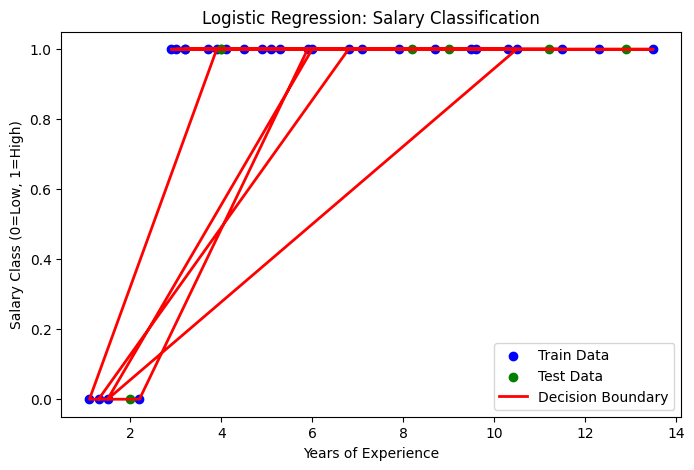


Predicted class for 5.0 years of experience: High Salary


C:\Users\Raja\Desktop\Project1\sara\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv("Salary.csv")


X = df[["YearsExperience"]]


df["SalaryClass"] = df["Salary"].apply(lambda s: 1 if s > 50000 else 0)
y = df["SalaryClass"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print(f"Training Accuracy: {model.score(X_train, y_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred):.4f}")


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))


print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    labels=[0, 1],
    target_names=["Low Salary", "High Salary"]
))


plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="blue", label="Train Data")
plt.scatter(X_test, y_test, color="green", label="Test Data")
plt.plot(X_train, model.predict(X_train), color="red", linewidth=2, label="Decision Boundary")
plt.title("Logistic Regression: Salary Classification")
plt.xlabel("Years of Experience")
plt.ylabel("Salary Class (0=Low, 1=High)")
plt.legend()
plt.show()


custom_exp = [[5.0]]
predicted_class = model.predict(custom_exp)[0]
print(
    f"\nPredicted class for {custom_exp[0][0]} years of experience: {'High Salary' if predicted_class == 1 else 'Low Salary'}"
)
